# Machine Learning for Physicists — Part 1
## Linear Regression, Error Metrics & Model Fitting

**PHY432 — Computational Methods in Physics**  
Arizona State University

---

## What this notebook covers

Machine learning sounds intimidating, but at its core it is something you already know: **fitting a model to data**. In this notebook we will:

1. Understand what **supervised learning** means in plain terms
2. Fit a **linear model** to Hooke's Law data using NumPy
3. Learn three ways to measure how good a fit is: **MSE, MAE, and R²**
4. Understand **gradient descent** — the algorithm that trains almost every ML model
5. See what happens when a model is too simple (**underfitting**) or too complex (**overfitting**)

---

In [2]:
# Standard imports — the same libraries we use throughout PHY432
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 12

# Fix the random seed so everyone gets the same results
np.random.seed(42)

---
## 1. What Is Supervised Learning?

In a physics experiment you measure pairs of values — for example, spring extension $x$ and force $F$. You then fit a model $F = kx$ to find the spring constant $k$.

That is **supervised learning** — learning a rule from labelled examples:

| What you know in physics | ML name |
|---|---|
| Your measurements $(x_i, F_i)$ | **Training data** |
| The model $F = kx + b$ | **Model** |
| Finding the best $k$ and $b$ | **Training / fitting** |
| Predicting $F$ for a new $x$ | **Inference** |

> **Bottom line:** If you have ever fit a line to data in a physics lab, you have already done supervised machine learning.

Two main flavours:
- **Regression** — predicting a number (force, temperature, energy level)
- **Classification** — predicting a category (signal vs background, phase of matter)

This notebook is about **regression**. Notebook 2 covers classification.

---

---
## 2. A Simple Physics Dataset: Hooke's Law

Hooke's Law says the force needed to stretch a spring by distance $x$ is:
$$F = k\,x$$

In a real experiment, every measurement has a small random error. We model this as:
$$F_i^{\text{measured}} = k\,x_i + b + \text{noise}_i$$

- $k$ = spring constant (what we want to find)
- $b$ = small offset (e.g. due to friction or sensor drift)
- noise = random measurement error

Let's generate some realistic noisy data and plot it.

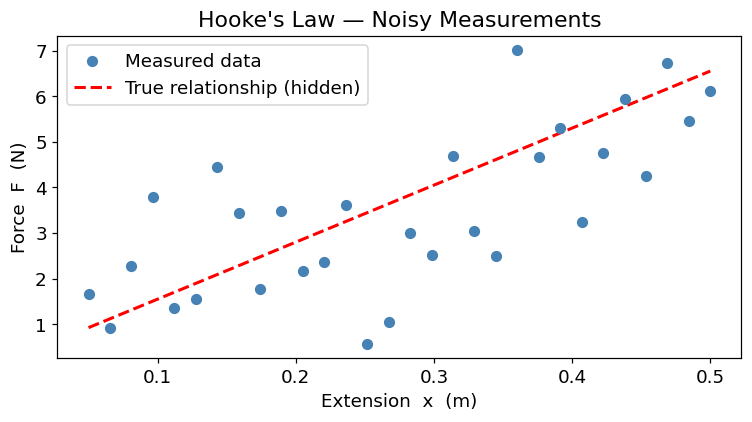

True spring constant: k = 12.5 N/m
True offset:          b = 0.3 N
We have 30 noisy measurements. Can we recover k and b?


In [3]:
# True (unknown) parameters — in a real experiment we are trying to find these
k_true = 12.5   # N/m   spring constant
b_true =  0.3   # N     small offset
sigma  =  1.5   # N     noise level (standard deviation of measurement error)

# Generate 30 measurements
N = 30
x_data = np.linspace(0.05, 0.50, N)                          # extension in metres
noise  = np.random.normal(loc=0, scale=sigma, size=N)        # random noise
y_data = k_true * x_data + b_true + noise                    # measured force (N)

# Plot the data
plt.figure(figsize=(7, 4))
plt.scatter(x_data, y_data, color='steelblue', s=40, label='Measured data', zorder=3)
plt.plot(x_data, k_true * x_data + b_true, 'r--', linewidth=2, label='True relationship (hidden)')
plt.xlabel('Extension  x  (m)')
plt.ylabel('Force  F  (N)')
plt.title("Hooke's Law — Noisy Measurements")
plt.legend()
plt.tight_layout()
plt.show()

print(f"True spring constant: k = {k_true} N/m")
print(f"True offset:          b = {b_true} N")
print(f"We have {N} noisy measurements. Can we recover k and b?")

---
## 3. Measuring How Good a Fit Is: Error Metrics

Before we fit anything, we need to define what "good" means. How do we measure the gap between our model's predictions and the real measurements?

Let's say our model predicts $\hat{F}_i$ and the true measured force is $F_i$. The difference $F_i - \hat{F}_i$ is called the **residual** — how far off we were for that one point.

There are three standard metrics for summarising all the residuals into a single number:

---

### 3.1 Mean Absolute Error (MAE)

$$\text{MAE} = \frac{1}{N}\sum_{i=1}^{N} |F_i - \hat{F}_i|$$

**What it means:** The average size of an error, ignoring sign. If MAE = 0.8 N, your predictions are off by 0.8 N on average.  
**Units:** Same as your output (Newtons here) — easy to interpret.  
**Good when:** You want a metric that is not sensitive to occasional large outliers.

---

### 3.2 Mean Squared Error (MSE)

$$\text{MSE} = \frac{1}{N}\sum_{i=1}^{N} (F_i - \hat{F}_i)^2$$

**What it means:** The average *squared* error. Because errors are squared, large errors are penalised much more heavily than small ones.  
**Units:** Squared output units (N²) — harder to interpret directly, but mathematically convenient.  
**Good when:** Large errors are especially bad and should be strongly penalised.  
**Also note:** $\sqrt{\text{MSE}}$ is called the **Root Mean Squared Error (RMSE)** and has the same units as the output — easier to interpret than MSE.

#### Why does ML almost always use MSE, not MAE?
The absolute value $|z|$ has a kink at $z = 0$ — its derivative jumps from $-1$ to $+1$. This makes it harder to use gradient-based optimisers. The squared error $(F_i - \hat{F}_i)^2$ is smooth everywhere, so its derivative is always well-defined:
$$\frac{d}{d\hat{F}}(F - \hat{F})^2 = -2(F - \hat{F})$$
This smooth gradient is what gradient descent (Section 4) needs.

---

### 3.3 R² Score (Coefficient of Determination)

$$R^2 = 1 - \frac{\sum_i (F_i - \hat{F}_i)^2}{\sum_i (F_i - \bar{F})^2}$$

where $\bar{F} = \frac{1}{N}\sum_i F_i$ is the mean of the measured forces.

**What it means:** R² measures how much better your model is compared to just always guessing the mean value $\bar{F}$.

| R² value | Meaning |
|---|---|
| R² = 1.0 | Perfect fit — model explains all variation in the data |
| R² = 0.9 | Very good — model explains 90% of the variation |
| R² = 0.5 | Mediocre — only half the variation explained |
| R² = 0.0 | Model is no better than guessing the mean |
| R² < 0   | Model is *worse* than guessing the mean (something is wrong!) |

**Units:** None — R² is dimensionless and always between $-\infty$ and 1.  
**Good when:** You want a single number to communicate how well the model works to someone unfamiliar with the units of your data.

---

In [4]:
# --- Implement all three metrics from scratch ---

def mae(y_true, y_pred):
    """Mean Absolute Error."""
    return np.mean(np.abs(y_true - y_pred))

def mse(y_true, y_pred):
    """Mean Squared Error."""
    return np.mean((y_true - y_pred)**2)

def rmse(y_true, y_pred):
    """Root Mean Squared Error — same units as y."""
    return np.sqrt(mse(y_true, y_pred))

def r2(y_true, y_pred):
    """R² score. 1.0 = perfect, 0.0 = no better than predicting the mean."""
    ss_residual = np.sum((y_true - y_pred)**2)   # sum of squared residuals
    ss_total    = np.sum((y_true - np.mean(y_true))**2)  # total variance in data
    return 1 - ss_residual / ss_total


# Demonstrate on a simple example: compare two candidate models
x_demo = x_data
y_demo = y_data

y_good = 12.5 * x_demo + 0.3   # close to truth
y_bad  = 5.0  * x_demo + 3.0   # wrong slope and intercept
y_mean = np.full_like(y_demo, np.mean(y_demo))  # always predict the mean

print("Comparing three candidate models on the Hooke's Law data:\n")
print(f"{'Model':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 52)
for label, y_pred in [("Good fit (k=12.5)", y_good),
                       ("Bad fit  (k=5.0)",  y_bad),
                       ("Always predict mean", y_mean)]:
    print(f"{label:<25} {mae(y_demo, y_pred):>8.3f} {rmse(y_demo, y_pred):>8.3f} {r2(y_demo, y_pred):>8.3f}")

print("\nUnits: MAE and RMSE are in Newtons. R² is dimensionless.")
print("R²=0 for 'always predict mean' — that model is our baseline.")

Comparing three candidate models on the Hooke's Law data:

Model                          MAE     RMSE       R²
----------------------------------------------------
Good fit (k=12.5)            1.095    1.357    0.396
Bad fit  (k=5.0)             1.352    1.644    0.113
Always predict mean          1.458    1.746    0.000

Units: MAE and RMSE are in Newtons. R² is dimensionless.
R²=0 for 'always predict mean' — that model is our baseline.


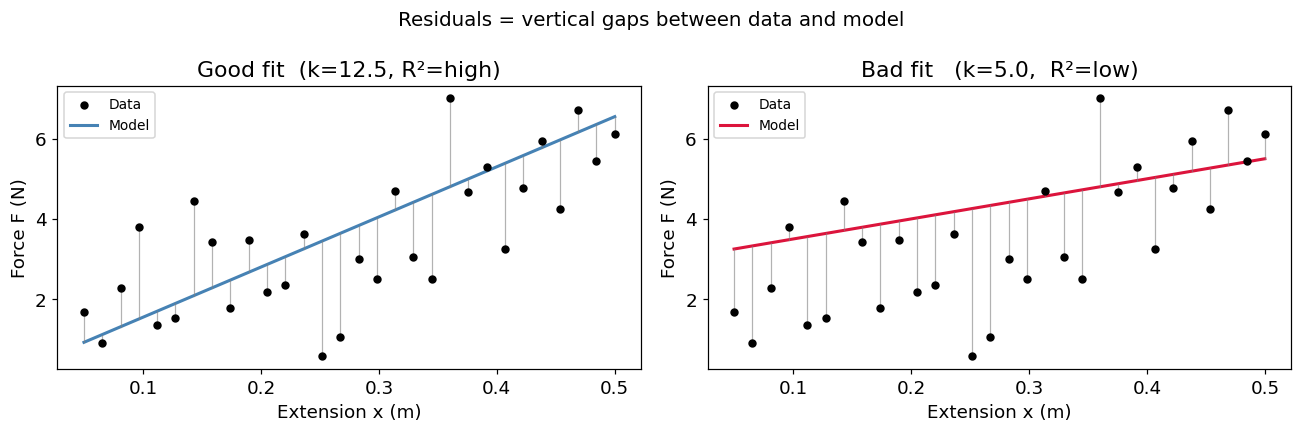

The gray vertical lines are the residuals (errors) for each data point.
MAE and RMSE measure the average size of these lines.
R² measures how much smaller these lines are compared to just guessing the mean.


In [5]:
# Visualise the residuals for each model
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, label, color in [
        (axes[0], y_good, 'Good fit  (k=12.5, R²=high)', 'steelblue'),
        (axes[1], y_bad,  'Bad fit   (k=5.0,  R²=low)',  'crimson')]:
    ax.scatter(x_demo, y_demo, color='black', s=20, zorder=5, label='Data')
    ax.plot(x_demo, y_pred, color=color, linewidth=2, label='Model')
    # Draw vertical lines showing residuals
    for xi, yi, ypi in zip(x_demo, y_demo, y_pred):
        ax.plot([xi, xi], [yi, ypi], color='gray', linewidth=0.8, alpha=0.6)
    ax.set_xlabel('Extension x (m)')
    ax.set_ylabel('Force F (N)')
    ax.set_title(label)
    ax.legend(fontsize=9)

plt.suptitle('Residuals = vertical gaps between data and model', fontsize=13)
plt.tight_layout()
plt.show()

print("The gray vertical lines are the residuals (errors) for each data point.")
print("MAE and RMSE measure the average size of these lines.")
print("R² measures how much smaller these lines are compared to just guessing the mean.")

---
## 4. Finding the Best Fit: The Normal Equations

Now let's actually *find* the best parameters $k$ and $b$. We want to minimise the MSE:

$$\text{MSE} = \frac{1}{N}\sum_{i=1}^{N}(F_i - (k\,x_i + b))^2$$

For a linear model, there is an exact formula called the **Normal Equations**:

$$\begin{pmatrix} b \\ k \end{pmatrix} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{F}$$

where $\mathbf{X}$ is a matrix with a column of ones (for $b$) and a column of $x$ values (for $k$):

$$\mathbf{X} = \begin{pmatrix} 1 & x_1 \\ 1 & x_2 \\ \vdots & \vdots \\ 1 & x_N \end{pmatrix}$$

To go from the MSE to this expression, we take derivatives of the MSE with respect to $b$ and $k$, set them to zero, and solve the resulting system of equations. Writing this system in matrix form leads directly to the normal equation above.

This is called the **design matrix**. The column of ones is how the intercept $b$ enters the calculation.

> **Note:** We use `np.linalg.solve(A, b)` rather than computing the matrix inverse directly. `solve` is more numerically stable and faster.

In [6]:
# Step 1: Build the design matrix
# Shape: (N, 2)  — N rows, 2 columns (ones and x values)
X_design = np.column_stack([np.ones(N), x_data])

print("Design matrix (first 5 rows):")
print("  [ones column,  x column]")
print(X_design[:5])

# Step 2: Solve the Normal Equations
params = np.linalg.solve(X_design.T @ X_design, X_design.T @ y_data)
b_fit, k_fit = params[0], params[1]

print(f"\n=== Fitted parameters ===")
print(f"  k (spring constant) = {k_fit:.4f} N/m   (true value: {k_true} N/m)")
print(f"  b (offset)          = {b_fit:.4f} N     (true value: {b_true} N)")

# Step 3: Evaluate on the data
y_fit = k_fit * x_data + b_fit

print(f"\n=== Model performance ===")
print(f"  MAE  = {mae(y_data, y_fit):.3f} N   (average error in Newtons)")
print(f"  RMSE = {rmse(y_data, y_fit):.3f} N   (noise level was sigma={sigma} N)")
print(f"  R²   = {r2(y_data, y_fit):.4f}      (fraction of variance explained)")

Design matrix (first 5 rows):
  [ones column,  x column]
[[1.         0.05      ]
 [1.         0.06551724]
 [1.         0.08103448]
 [1.         0.09655172]
 [1.         0.11206897]]

=== Fitted parameters ===
  k (spring constant) = 9.1032 N/m   (true value: 12.5 N/m)
  b (offset)          = 0.9519 N     (true value: 0.3 N)

=== Model performance ===
  MAE  = 1.021 N   (average error in Newtons)
  RMSE = 1.246 N   (noise level was sigma=1.5 N)
  R²   = 0.4904      (fraction of variance explained)


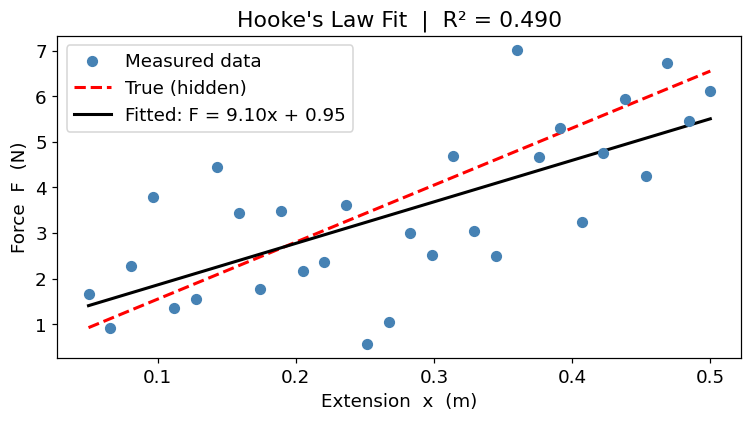

The black fitted line and the red true line are very close — the fit worked!
Small differences remain because of measurement noise.


In [7]:
# Plot: data, true line, and fitted line
plt.figure(figsize=(7, 4))
plt.scatter(x_data, y_data, color='steelblue', s=40, label='Measured data', zorder=3)
plt.plot(x_data, k_true * x_data + b_true, 'r--', linewidth=2, label='True (hidden)')
plt.plot(x_data, y_fit, 'k-', linewidth=2,
         label=f'Fitted: F = {k_fit:.2f}x + {b_fit:.2f}')
plt.xlabel('Extension  x  (m)')
plt.ylabel('Force  F  (N)')
plt.title(f"Hooke's Law Fit  |  R² = {r2(y_data, y_fit):.3f}")
plt.legend()
plt.tight_layout()
plt.show()

print("The black fitted line and the red true line are very close — the fit worked!")
print("Small differences remain because of measurement noise.")

---
## 5. Gradient Descent — How ML Actually Learns

The Normal Equations give the exact answer for linear models. But for more complex models (like neural networks in Notebook 2) there is no closed-form formula. Instead, we use **gradient descent**.

### The idea in plain language

Think of the MSE as a hilly landscape, with the parameters $k$ and $b$ as your position. You want to walk to the lowest point (smallest MSE).

**Gradient descent:** At each step, check which direction the hill slopes downward, and take a small step in that direction.

Mathematically, the slope of the MSE with respect to each parameter is the **gradient**:

$$\frac{\partial\,\text{MSE}}{\partial b} = -\frac{2}{N}\sum_i(F_i - \hat{F}_i)$$

$$\frac{\partial\,\text{MSE}}{\partial k} = -\frac{2}{N}\sum_i(F_i - \hat{F}_i)\cdot x_i$$

Then update the parameters by taking a step *downhill*:

$$k \leftarrow k - \alpha \cdot \frac{\partial\,\text{MSE}}{\partial k}$$
$$b \leftarrow b - \alpha \cdot \frac{\partial\,\text{MSE}}{\partial b}$$

The number $\alpha$ is the **learning rate** — how big a step to take each iteration. Repeat this hundreds or thousands of times until the MSE stops improving.

> **Key point:** The $-$ sign is because the gradient points *uphill*. We subtract it to go *downhill*.

In [8]:
def gradient_descent(x, y, learning_rate=0.5, n_steps=500):
    """
    Fit a linear model y = k*x + b using gradient descent.

    Parameters
    ----------
    x             : input data
    y             : target data
    learning_rate : step size per iteration (alpha)
    n_steps       : how many gradient steps to take

    Returns
    -------
    k, b      : fitted parameters
    mse_log   : list of MSE at each step (useful for plotting convergence)
    """
    N = len(x)
    k, b = 0.0, 0.0     # start from zero — gradient descent will find the answer
    mse_log = []

    for step in range(n_steps):
        y_hat    = k * x + b               # current predictions
        residual = y - y_hat               # errors (positive = underpredicted)

        # Gradients — derived by differentiating MSE with respect to k and b
        grad_k = -2/N * np.sum(residual * x)   # dMSE/dk
        grad_b = -2/N * np.sum(residual)        # dMSE/db

        # Take a step downhill
        k = k - learning_rate * grad_k
        b = b - learning_rate * grad_b

        mse_log.append(np.mean(residual**2))

    return k, b, mse_log


k_gd, b_gd, loss_history = gradient_descent(x_data, y_data,
                                             learning_rate=0.5, n_steps=400)

print("=== Gradient Descent Result ===")
print(f"  k = {k_gd:.4f}   (Normal Equations: {k_fit:.4f})")
print(f"  b = {b_gd:.4f}   (Normal Equations: {b_fit:.4f})")
print("\nBoth methods give essentially the same answer.")

=== Gradient Descent Result ===
  k = 9.0936   (Normal Equations: 9.1032)
  b = 0.9546   (Normal Equations: 0.9519)

Both methods give essentially the same answer.


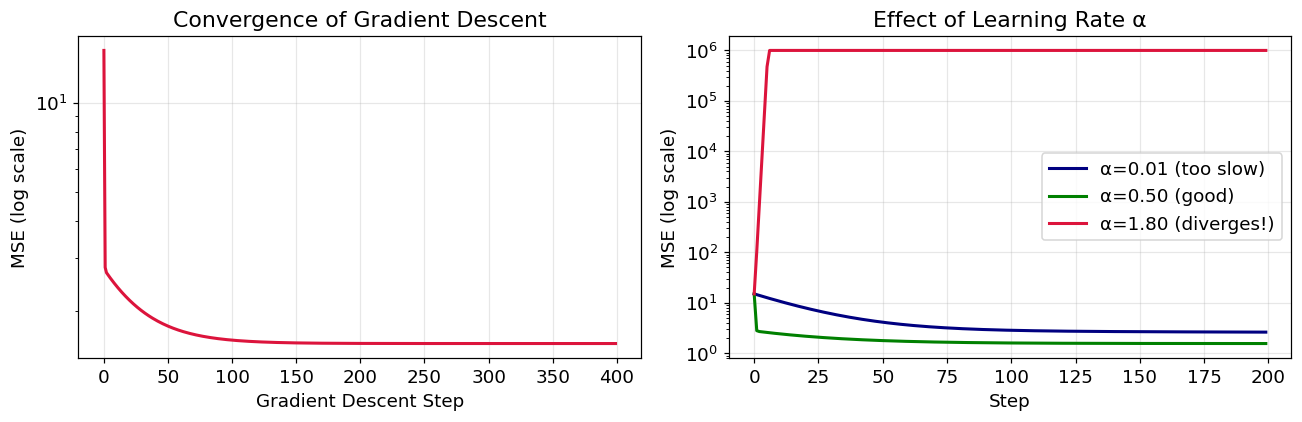

Left:  MSE drops quickly at first, then flattens when near the minimum.
Right: Learning rate too small → slow. Too large → MSE blows up (diverges!).


In [9]:
# Plot: how the MSE drops as gradient descent runs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(loss_history, color='crimson', linewidth=2)
axes[0].set_xlabel('Gradient Descent Step')
axes[0].set_ylabel('MSE (log scale)')
axes[0].set_title('Convergence of Gradient Descent')
axes[0].grid(True, alpha=0.3)

# Show what different learning rates do
for lr, color, label in [(0.01, 'navy',   'α=0.01 (too slow)'),
                          (0.5,  'green',  'α=0.50 (good)'),
                          (1.8,  'crimson','α=1.80 (diverges!)')]:
    _, _, log = gradient_descent(x_data, y_data, learning_rate=lr, n_steps=200)
    axes[1].semilogy(np.clip(log, 1e-2, 1e6), color=color, linewidth=2, label=label)

axes[1].set_xlabel('Step')
axes[1].set_ylabel('MSE (log scale)')
axes[1].set_title('Effect of Learning Rate α')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Left:  MSE drops quickly at first, then flattens when near the minimum.")
print("Right: Learning rate too small → slow. Too large → MSE blows up (diverges!).")

---
## 6. Overfitting and Underfitting

So far we used a simple linear model, which works well for Hooke's Law. But what if the true relationship is more complex — like the range of a projectile as a function of launch angle?

$$R(\phi) = \frac{v_0^2}{g}\sin(2\phi)$$

This is *not* a straight line. We can still use the linear-algebra approach by adding **polynomial features** — extra columns $x^2, x^3, \ldots$ to the design matrix. The parameters $\theta_0, \theta_1, \theta_2, \ldots$ remain linear even though the fit is curved.

The **degree** of the polynomial controls how flexible the model is:

- **Degree too low** → **Underfitting** — model is too simple; misses the real pattern
- **Degree just right** → Good fit — captures the physics without memorising noise  
- **Degree too high** → **Overfitting** — model memorises noise and wiggles wildly

In [10]:
# --- Projectile range data ---
v0, g = 20.0, 9.81

phi_all  = np.linspace(10, 80, 200) * np.pi / 180
R_true   = (v0**2 / g) * np.sin(2 * phi_all)

# 18 noisy training measurements
phi_train = np.linspace(10, 80, 18) * np.pi / 180
R_train   = (v0**2 / g) * np.sin(2 * phi_train) + np.random.normal(0, 1.5, 18)

# Normalise phi to [0,1] so that high powers don't become numerically huge
phi_min, phi_max = phi_all.min(), phi_all.max()
phi_n       = (phi_all   - phi_min) / (phi_max - phi_min)
phi_train_n = (phi_train - phi_min) / (phi_max - phi_min)

# Helper functions
def poly_design(x, degree):
    """Design matrix with columns [1, x, x^2, ..., x^degree]."""
    return np.column_stack([x**d for d in range(degree + 1)])

def poly_fit_and_predict(x_train, y_train, x_pred, degree):
    """Fit polynomial and return predictions."""
    X = poly_design(x_train, degree)
    theta = np.linalg.lstsq(X, y_train, rcond=None)[0]
    return poly_design(x_pred, degree) @ theta, theta

print("Data ready. Now let's try different polynomial degrees...")

Data ready. Now let's try different polynomial degrees...


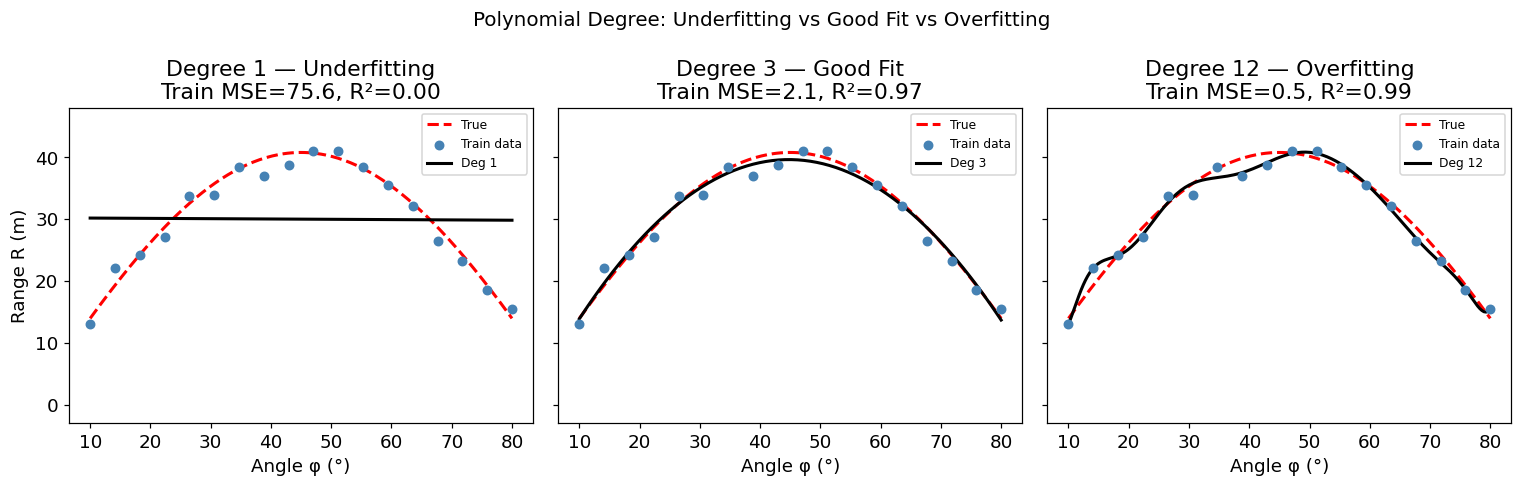


Degree 1 (Underfitting):
  A straight line cannot capture the arc shape of sin(2φ). The model is too simple.
  Both train AND test error are high. R² is low.

Degree 3 (Good fit):
  Captures the arc shape well. The curve follows the true relationship closely.
  R² is high, and the model will predict well for new angles.

Degree 12 (Overfitting):
  The model has 13 parameters for only 18 data points. It threads through every
  training point (including noise), but oscillates wildly between them.
  Training R² looks great, but the model fails on any new data!



In [11]:
# Compare degree 1, 3, and 12
degrees = [1, 3, 12]
titles  = ['Degree 1 — Underfitting', 'Degree 3 — Good Fit', 'Degree 12 — Overfitting']

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for ax, deg, title in zip(axes, degrees, titles):
    R_pred, _ = poly_fit_and_predict(phi_train_n, R_train, phi_n, deg)
    train_mse = mse(R_train, poly_fit_and_predict(phi_train_n, R_train, phi_train_n, deg)[0])
    train_r2  = r2(R_train,  poly_fit_and_predict(phi_train_n, R_train, phi_train_n, deg)[0])

    ax.plot(phi_all * 180/np.pi, R_true, 'r--', linewidth=2, label='True')
    ax.scatter(phi_train * 180/np.pi, R_train, color='steelblue', s=30, zorder=5, label='Train data')
    ax.plot(phi_all * 180/np.pi, np.clip(R_pred, -5, 50), 'k-', linewidth=2, label=f'Deg {deg}')
    ax.set_ylim(-3, 48)
    ax.set_title(f'{title}\nTrain MSE={train_mse:.1f}, R²={train_r2:.2f}')
    ax.set_xlabel('Angle φ (°)')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Range R (m)')
plt.suptitle('Polynomial Degree: Underfitting vs Good Fit vs Overfitting', fontsize=13)
plt.tight_layout()
plt.show()

print("""
Degree 1 (Underfitting):
  A straight line cannot capture the arc shape of sin(2φ). The model is too simple.
  Both train AND test error are high. R² is low.

Degree 3 (Good fit):
  Captures the arc shape well. The curve follows the true relationship closely.
  R² is high, and the model will predict well for new angles.

Degree 12 (Overfitting):
  The model has 13 parameters for only 18 data points. It threads through every
  training point (including noise), but oscillates wildly between them.
  Training R² looks great, but the model fails on any new data!
""")

### 6.1 Train vs Test Error: How to Spot Overfitting

The key tool for detecting overfitting is splitting your data into two parts:

- **Training set** — the data used to fit the model
- **Test set** — held-out data the model has *never seen*, used to evaluate the final result

If training error is very low but test error is high, the model is overfitting.

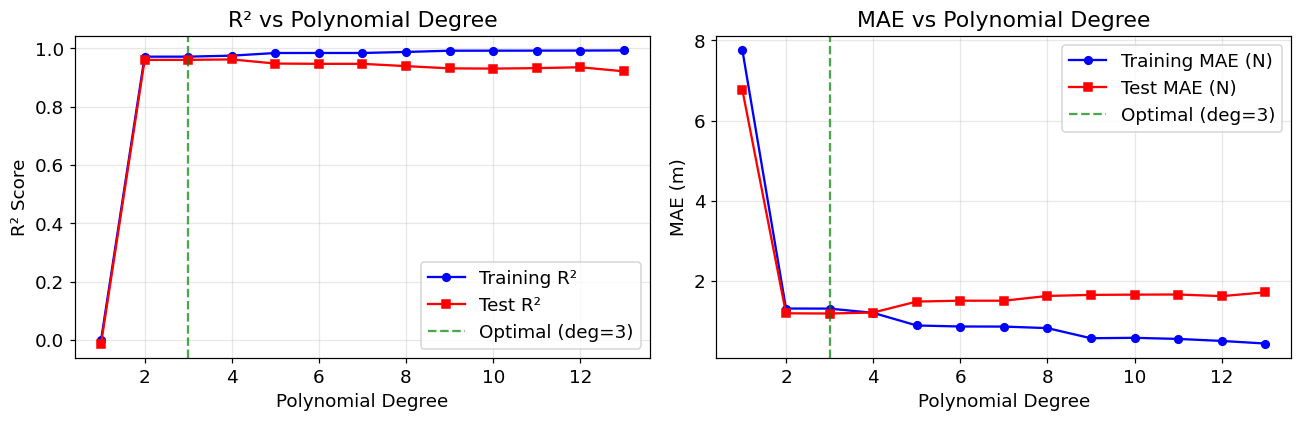


Reading these plots:

R² plot:
  - Training R² (blue) keeps rising with degree — a more complex model always
    fits training data better. This is misleading on its own.
  - Test R² (red) rises, peaks around degree 3, then DROPS — the model is
    starting to memorise training noise instead of learning real physics.

MAE plot:
  - Training MAE always drops. But test MAE reaches a minimum then rises.
  - The gap between training and test error is the 'overfitting gap'.

KEY RULE: Always choose your model based on TEST performance, not training performance.
The best degree is where test error is lowest — not where training error is lowest.



In [12]:
# Generate a test set (new data from the same physics)
phi_test  = np.sort(np.random.uniform(phi_all.min(), phi_all.max(), 60))
R_test    = (v0**2 / g) * np.sin(2 * phi_test) + np.random.normal(0, 1.5, 60)
phi_test_n = (phi_test - phi_min) / (phi_max - phi_min)

# Compute train and test metrics for each polynomial degree
degrees_all = range(1, 14)
train_r2_list, test_r2_list   = [], []
train_mae_list, test_mae_list = [], []

for deg in degrees_all:
    R_pred_train, _ = poly_fit_and_predict(phi_train_n, R_train, phi_train_n, deg)
    R_pred_test,  _ = poly_fit_and_predict(phi_train_n, R_train, phi_test_n,  deg)

    train_r2_list.append(r2( R_train, R_pred_train))
    test_r2_list.append( r2( R_test,  R_pred_test))
    train_mae_list.append(mae(R_train, R_pred_train))
    test_mae_list.append( mae(R_test,  R_pred_test))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# R² plot
axes[0].plot(degrees_all, train_r2_list, 'b-o', markersize=5, label='Training R²')
axes[0].plot(degrees_all, test_r2_list,  'r-s', markersize=5, label='Test R²')
axes[0].axvline(x=3, color='green', linestyle='--', alpha=0.7, label='Optimal (deg=3)')
axes[0].set_xlabel('Polynomial Degree')
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² vs Polynomial Degree')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE plot
axes[1].plot(degrees_all, train_mae_list, 'b-o', markersize=5, label='Training MAE (N)')
axes[1].plot(degrees_all, test_mae_list,  'r-s', markersize=5, label='Test MAE (N)')
axes[1].axvline(x=3, color='green', linestyle='--', alpha=0.7, label='Optimal (deg=3)')
axes[1].set_xlabel('Polynomial Degree')
axes[1].set_ylabel('MAE (m)')
axes[1].set_title('MAE vs Polynomial Degree')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("""
Reading these plots:

R² plot:
  - Training R² (blue) keeps rising with degree — a more complex model always
    fits training data better. This is misleading on its own.
  - Test R² (red) rises, peaks around degree 3, then DROPS — the model is
    starting to memorise training noise instead of learning real physics.

MAE plot:
  - Training MAE always drops. But test MAE reaches a minimum then rises.
  - The gap between training and test error is the 'overfitting gap'.

KEY RULE: Always choose your model based on TEST performance, not training performance.
The best degree is where test error is lowest — not where training error is lowest.
""")

---
## 7. Summary

### Error Metrics — Quick Reference

| Metric | Formula | Units | Best when... |
|---|---|---|---|
| **MAE** | $\frac{1}{N}\sum(y_i - \hat y_i)$ | Same as $y$ | You want simple, interpretable average error |
| **MSE** | $\frac{1}{N}\sum(y_i - \hat y_i)^2$ | $y^2$ (squared) | Large errors matter more; used as loss for training |
| **RMSE** | $\sqrt{\text{MSE}}$ | Same as $y$ | Same as MSE but more interpretable |
| **R²** | $1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$ | None (0 to 1) | Communicating quality as a percentage |

### Key Ideas

| Concept | Plain explanation |
|---|---|
| **Supervised learning** | Fitting a model to labelled examples — you already know this from lab curve fitting |
| **Normal equations** | Exact closed-form solution for linear models |
| **Gradient descent** | Universal iterative method — moves downhill in error landscape |
| **Learning rate** | Step size in gradient descent; too big → diverges, too small → very slow |
| **Underfitting** | Model too simple; misses real patterns; both train and test error are high |
| **Overfitting** | Model too complex; memorises noise; train error low but test error high |
| **Train/test split** | Never judge a model on the data used to fit it — always use held-out data |



